## ex00_line_chart


In [1]:
import pandas as pd
import sqlite3

### подключитесь к базе данных


In [2]:
conn = sqlite3.connect("../data/checking-logs.sqlite")
cur = conn.cursor()

### выполните запрос, который получает дату и время из таблицы просмотров страниц, выбирая только пользователей, а не администраторов


In [3]:
data = pd.read_sql(
    """

                SELECT uid, datetime FROM pageviews

                WHERE uid LIKE 'user%'

            """,

    conn,
    parse_dates="datetime",
)

data

,uid,datetime
0,user_30,2020-04-17 22:46:26.785035
1,user_14,2020-04-18 10:53:52.623447
2,user_17,2020-04-18 10:56:55.833899
3,user_14,2020-04-18 10:57:37.331258
4,user_17,2020-04-18 12:05:48.200144
...,...,...
982,user_28,2020-05-21 18:45:20.441142
983,user_19,2020-05-21 23:03:06.457819
984,user_25,2020-05-21 23:23:49.995349
985,user_5,2020-05-22 11:30:18.368990


### с помощью Pandas создайте новый фрейм данных, в котором подсчитываются посещения и группируются по дате


In [4]:
data["date"] = data["datetime"].dt.date
df = data.groupby(data["date"]).date.count()
df

date
2020-04-17      1
2020-04-18     23
2020-04-19     15
2020-04-21      3
2020-04-22      1
2020-04-23      5
2020-04-25      1
2020-04-26      8
2020-04-28      2
2020-04-29      4
2020-04-30      9
2020-05-01      3
2020-05-02      6
2020-05-03     19
2020-05-04      1
2020-05-05      1
2020-05-06      3
2020-05-07      2
2020-05-08     48
2020-05-09     19
2020-05-10    110
2020-05-11    200
2020-05-12     85
2020-05-13    102
2020-05-14    187
2020-05-15     29
2020-05-16      4
2020-05-17      9
2020-05-18     51
2020-05-19     11
2020-05-20     12
2020-05-21     11
2020-05-22      2
Name: date, dtype: int64

In [5]:
df.info()

<class 'pandas.core.series.Series'>
Index: 33 entries, 2020-04-17 to 2020-05-22
Series name: date
Non-Null Count  Dtype
--------------  -----
33 non-null     int64
dtypes: int64(1)
memory usage: 1.6+ KB


### используя метод Pandas .plot(), создайте график


<Axes: title={'center': 'Views per day'}, xlabel='date'>

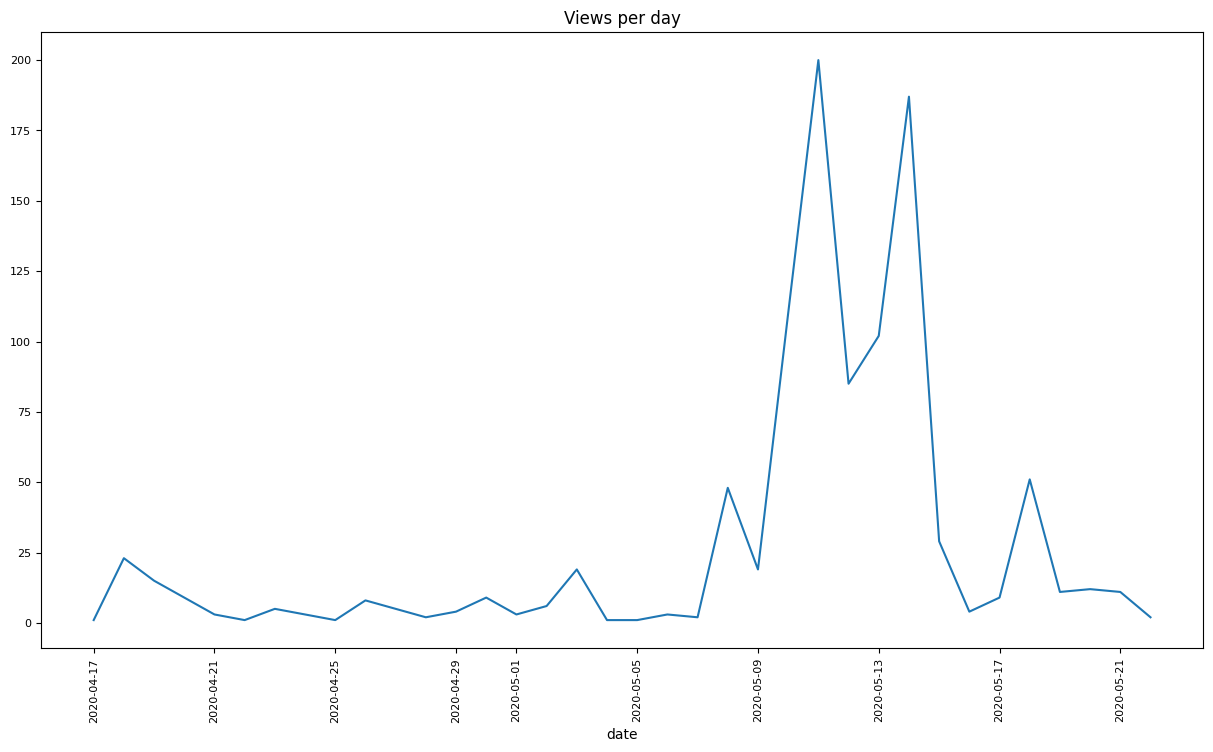

In [6]:
df.plot(title="Views per day", fontsize=8, figsize=(15, 8), rot=90)

### закройте подключение к базе данных


In [7]:
conn.close()